# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Transformers ─────────────────────────────────────────
from transformers import AutoTokenizer, AutoModel, AlbertModel, AlbertTokenizer, BertTokenizer

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "./05_SoftLabel_TrainAll"
RAW_DATA_FILE = "data/mental_health_unified_labels_final.csv"
OUTPUT_DIR = "outputs"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-v1.1"

TEXT_COLUMN = "statement"

# ── 7-class mental health ────────────────────────────────
CLASS_NAMES = ["NORMAL", "DEPRESSION", "ANXIETY", "SUICIDAL", "STRESS", "BIPOLAR", "PERSONALITY_DISORDER"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Soft-label columns (pre-computed in CSV) ─────────────
SOFT_COLS = ["u_p_normal", "u_p_depression", "u_p_anxiety", "u_p_suicidal", "u_p_stress", "u_p_bipolar", "u_p_personality_disorder"]
LABEL_COLUMN = "u_label"
SPECIAL_LABELS = {"OUT_OF_SCOPE", "INSUFFICIENT"}
LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 4

# ── A100 optimizations ──────────────────────────────────
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
print(f"BF16: {USE_BF16}")

# ── Retrain flag ─────────────────────────────────────────
RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_soft_all.pth",
        "params": OUTPUT_PATH / "best_albert_soft_all_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_soft_all.pth",
        "params": OUTPUT_PATH / "best_biobert_soft_all_params.json",
    },
}

print("--- 7-Class Soft-Label Configuration (Mental Health) ---")
print(f"  Project    : {DRIVE_PROJECT_PATH}")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Soft cols  : {SOFT_COLS}")
print(f"  Label col  : {LABEL_COLUMN}")

BF16: True
--- 7-Class Soft-Label Configuration (Mental Health) ---
  Project    : ./05_SoftLabel_TrainAll
  Classes    : ['NORMAL', 'DEPRESSION', 'ANXIETY', 'SUICIDAL', 'STRESS', 'BIPOLAR', 'PERSONALITY_DISORDER']
  Soft cols  : ['u_p_normal', 'u_p_depression', 'u_p_anxiety', 'u_p_suicidal', 'u_p_stress', 'u_p_bipolar', 'u_p_personality_disorder']
  Label col  : u_label


## 1.4 Mount drive & Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")
df_raw.head()

Loaded 53043 rows.


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [9]:
# ── SCOPE GATE: keep only evaluable posts ────────────────
before = len(df_raw)
df_raw = df_raw[~df_raw[LABEL_COLUMN].isin(SPECIAL_LABELS)].reset_index(drop=True)
print(f"Scope gating: {before} → {len(df_raw)} rows "
      f"(removed {before - len(df_raw)} OUT_OF_SCOPE/INSUFFICIENT)")
df_raw.head()

Scope gating: 53043 → 53043 rows (removed 0 OUT_OF_SCOPE/INSUFFICIENT)


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [10]:
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)

# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [11]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


### 2.1.2 Validate soft-label probability columns

In [12]:
print("\nValidating soft-label probability columns...")
for col in SOFT_COLS:
    if col not in df_clean.columns:
        raise ValueError(f"Missing column: {col}")
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0.0)

# Validate rows sum to ~1
row_sums = df_clean[SOFT_COLS].sum(axis=1)
print(f"  Probability row sums — min: {row_sums.min():.4f}, max: {row_sums.max():.4f}, mean: {row_sums.mean():.4f}")

# Normalize to ensure sum = 1
soft_array = df_clean[SOFT_COLS].to_numpy(dtype=np.float32)
soft_array = soft_array / np.clip(soft_array.sum(axis=1, keepdims=True), 1e-8, None)

for i, col in enumerate(SOFT_COLS):
    df_clean[col] = soft_array[:, i]

# Hard label from u_label column
df_clean["y_hard"] = df_clean[LABEL_COLUMN].map(LABEL_MAP)
n_unmapped = df_clean["y_hard"].isna().sum()
if n_unmapped > 0:
    print(f"  WARNING: {n_unmapped} unmapped labels — dropping")
    df_clean = df_clean.dropna(subset=["y_hard"]).reset_index(drop=True)
    soft_array = df_clean[SOFT_COLS].to_numpy(dtype=np.float32)
df_clean["y_hard"] = df_clean["y_hard"].astype(int)

print(f"\n{LABEL_COLUMN} distribution:")
print(df_clean[LABEL_COLUMN].value_counts())


Validating soft-label probability columns...
  Probability row sums — min: 0.4000, max: 4.0000, mean: 1.0038

u_label distribution:
u_label
NORMAL                  19921
SUICIDAL                12145
DEPRESSION               9688
ANXIETY                  7550
STRESS                   2119
BIPOLAR                  1213
PERSONALITY_DISORDER      407
Name: count, dtype: int64


## 2.2 Master Data Split

In [13]:
groups = df_clean[TEXT_COLUMN]
y_for_split = df_clean["y_hard"]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval["y_hard"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_soft_all.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved master split → {split_path}")


Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Saved master split → ./05_SoftLabel_TrainAll/outputs/master_split_soft_all.csv


# 3. ALBERT & BioBERT Models (soft training/validation/testing)


## 3.1 Shared helper functions

In [14]:
def bootstrap_ci_mean(values: np.ndarray, n_iterations: int = 1000) -> Tuple[float, float, float]:
    """Bootstrap CI for the MEAN of a per-sample metric array."""
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    idx_all = np.arange(n)
    boot_means = []
    for _ in range(n_iterations):
        idx = resample(idx_all)
        boot_means.append(values[idx].mean())
    boot_means = np.asarray(boot_means, dtype=np.float64)
    return float(values.mean()), float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))


def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx],
                              average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


# ── Soft metrics ─────────────────────────────────────────

def per_sample_soft_ce(probs_np, soft_targets_np, eps=1e-12):
    """Per-sample Soft CE: -sum_k soft_k * log(p_k)"""
    probs = np.clip(np.asarray(probs_np, dtype=np.float64), eps, 1.0)
    soft = np.asarray(soft_targets_np, dtype=np.float64)
    return -np.sum(soft * np.log(probs), axis=1)


def per_sample_brier(probs_np, soft_targets_np):
    """Per-sample multiclass Brier: sum_k (p_k - soft_k)^2"""
    probs = np.asarray(probs_np, dtype=np.float64)
    soft = np.asarray(soft_targets_np, dtype=np.float64)
    return np.sum((probs - soft) ** 2, axis=1)


def bootstrap_soft_ce_ci(probs_np, soft_targets_np, n_iterations=1000):
    values = per_sample_soft_ce(probs_np, soft_targets_np)
    return bootstrap_ci_mean(values, n_iterations=n_iterations)


def bootstrap_brier_ci(probs_np, soft_targets_np, n_iterations=1000):
    values = per_sample_brier(probs_np, soft_targets_np)
    return bootstrap_ci_mean(values, n_iterations=n_iterations)


# ── Plots ────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, class_names, title="Model", save_dir=None):
    y_true_bin = label_binarize(np.asarray(y_true, dtype=int),
                                classes=np.arange(len(class_names)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", len(class_names))
    plt.figure(figsize=(10, 8))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{name} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


# ── High-level evaluators ────────────────────────────────

def evaluate_hard(y_true_hard, logits_np, class_names, model_tag="MODEL",
                  save_dir=None, n_boot=1000):
    """Hard evaluation: classification report + F1 CI + AUC CI + plots."""
    y_true_hard = np.asarray(y_true_hard, dtype=np.int64)
    probs = torch.softmax(torch.tensor(logits_np, dtype=torch.float32), dim=1).numpy()
    preds = probs.argmax(axis=1)

    print(f"\n{'='*60}")
    print(f"Evaluation (HARD): {model_tag}")
    print(f"{'='*60}")
    print(classification_report(
        y_true_hard, preds,
        labels=list(range(len(class_names))),
        target_names=class_names, digits=4, zero_division=0,
    ))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_true_hard, preds, n_iterations=n_boot)
    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_true_hard, probs, n_iterations=n_boot)

    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")
    print(f"Macro AUC:   {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_confusion_matrix(y_true_hard, preds, class_names,
                          title=f"{model_tag}_SoftAll", save_dir=save_dir)
    plot_multiclass_roc(y_true_hard, probs, class_names,
                        title=f"{model_tag}_SoftAll", save_dir=save_dir)

    return {
        "y_true": y_true_hard, "y_pred": preds, "y_prob": probs,
        "f1_weighted": f1_m, "f1_ci": (f1_lo, f1_hi),
        "auc_macro": auc_m, "auc_ci": (auc_lo, auc_hi),
    }


def evaluate_soft(probs_np, y_true_soft, model_tag="MODEL", n_boot=1000):
    """Soft evaluation: CE + Brier with bootstrap CIs."""
    probs_np = np.asarray(probs_np, dtype=np.float64)
    y_true_soft = np.asarray(y_true_soft, dtype=np.float64)

    ce_m, ce_lo, ce_hi = bootstrap_soft_ce_ci(probs_np, y_true_soft, n_iterations=n_boot)
    br_m, br_lo, br_hi = bootstrap_brier_ci(probs_np, y_true_soft, n_iterations=n_boot)

    print(f"\n--- Evaluation (SOFT): {model_tag} ---")
    print(f"Soft CE: {ce_m:.6f}  95% CI [{ce_lo:.6f}, {ce_hi:.6f}]")
    print(f"Brier:   {br_m:.6f}  95% CI [{br_lo:.6f}, {br_hi:.6f}]")

    return {
        "soft_ce": ce_m, "soft_ce_ci": (ce_lo, ce_hi),
        "brier": br_m, "brier_ci": (br_lo, br_hi),
    }

## 3.2 Data splits & labels

In [15]:
def _extract_soft(df):
    s = df[SOFT_COLS].to_numpy(dtype=np.float32)
    return s / np.clip(s.sum(axis=1, keepdims=True), 1e-8, None)

df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Soft labels for all splits
y_train_soft = _extract_soft(df_train)
y_val_soft   = _extract_soft(df_val)
y_test_soft  = _extract_soft(df_test)

# Hard labels (argmax) for evaluation
y_train_hard = df_train["y_hard"].to_numpy(dtype=np.int64)
y_val_hard   = df_val["y_hard"].to_numpy(dtype=np.int64)
y_test_hard  = df_test["y_hard"].to_numpy(dtype=np.int64)

print(f"Train soft: {y_train_soft.shape} | Val soft: {y_val_soft.shape} | Test soft: {y_test_soft.shape}")
print(f"Val  hard dist: {np.bincount(y_val_hard, minlength=NUM_CLASSES)}")
print(f"Test hard dist: {np.bincount(y_test_hard, minlength=NUM_CLASSES)}")

Train soft: (31976, 7) | Val soft: (10517, 7) | Test soft: (10550, 7)
Val  hard dist: [3824 1936 1532 2468  442  237   78]
Test hard dist: [3897 1949 1510 2433  427  245   89]


## 3.3 Generic soft-label model componets

In [16]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Dataset ──────────────────────────────────────────────
class SoftLabelDataset(Dataset):
    """Pre-tokenized dataset with optional soft and hard labels."""

    def __init__(self, input_ids, attention_masks,
                 hard_labels=None, soft_labels=None):
        self.input_ids = input_ids
        self.attention_masks = attention_masks

        self.soft_labels = None
        if soft_labels is not None:
            sl = np.asarray(soft_labels, dtype=np.float32)
            rs = sl.sum(axis=1, keepdims=True)
            self.soft_labels = sl / np.clip(rs, 1e-8, None)

        self.hard_labels = None
        if hard_labels is not None:
            self.hard_labels = np.asarray(hard_labels, dtype=np.int64)
        elif self.soft_labels is not None:
            self.hard_labels = self.soft_labels.argmax(axis=1).astype(np.int64)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        if self.hard_labels is not None:
            item["labels"] = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        if self.soft_labels is not None:
            item["soft_labels"] = torch.tensor(self.soft_labels[idx], dtype=torch.float32)
        return item


# ── Classifier ───────────────────────────────────────────
class TransformerClassifier(nn.Module):
    """Base transformer → dropout → linear → logits."""

    def __init__(self, base_model, hidden_size, num_classes=NUM_CLASSES,
                 dropout=0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls))


# ── Loss function ────────────────────────────────────────
def soft_cross_entropy(logits, soft_targets):
    """Soft-label CE: -sum_k soft_k * log_softmax(logits)_k"""
    log_probs = torch.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()


# ── Inference helper ─────────────────────────────────────
def predict_logits(model, loader, device=DEVICE):
    """Run inference, return (logits, hard_labels, soft_labels) as numpy."""
    model.eval()
    all_logits, all_labels, all_soft = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(ids, mask)

            all_logits.append(logits.float().cpu().numpy())
            if "labels" in batch:
                all_labels.append(batch["labels"].numpy())
            if "soft_labels" in batch:
                all_soft.append(batch["soft_labels"].numpy())
    return (
        np.concatenate(all_logits),
        np.concatenate(all_labels) if all_labels else None,
        np.concatenate(all_soft) if all_soft else None,
    )


# ── Training function ────────────────────────────────────
def train_soft_model(model, train_loader, val_loader,
                     lr=2e-5, max_epochs=6, patience=PATIENCE):
    """Train with soft CE + BF16 autocast.
    Best epoch selected by val weighted F1. Early stopping."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_f1, best_state, best_epoch = -1.0, None, -1
    best_val_soft_loss = np.inf
    no_improve = 0

    history = {"train_soft_loss": [], "val_soft_loss": [], "val_f1w": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            soft = batch["soft_labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(ids, mask)
                loss = soft_cross_entropy(logits, soft)

            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = float(np.mean(losses))

        # Validate
        model.eval()
        val_preds, val_true, val_losses_ep = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    logits = model(ids, mask)

                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["labels"].numpy())

                # Soft loss for monitoring
                if "soft_labels" in batch:
                    soft = batch["soft_labels"].to(DEVICE, non_blocking=True)
                    with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                        vloss = soft_cross_entropy(logits, soft)
                    val_losses_ep.append(vloss.item())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_soft_loss = float(np.mean(val_losses_ep)) if val_losses_ep else np.nan

        history["train_soft_loss"].append(train_loss)
        history["val_soft_loss"].append(val_soft_loss)
        history["val_f1w"].append(val_f1)

        print(f"  Epoch {epoch}/{max_epochs} | TrainLoss={train_loss:.4f} | "
              f"ValSoftLoss={val_soft_loss:.4f} | ValF1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            best_val_soft_loss = val_soft_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model, best_epoch, history


def build_loaders(tokenizer, model_label, include_val_soft=True):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True)

    # Train: soft labels for training
    train_loader = DataLoader(
        SoftLabelDataset(train_ids, train_masks, soft_labels=y_train_soft),
        shuffle=True, **loader_kw)

    # Val: both soft (for soft loss monitoring) and hard (for F1)
    val_loader = DataLoader(
        SoftLabelDataset(val_ids, val_masks,
                         soft_labels=y_val_soft if include_val_soft else None,
                         hard_labels=y_val_hard),
        shuffle=False, **loader_kw)

    # Test: both soft and hard for full evaluation
    test_loader = DataLoader(
        SoftLabelDataset(test_ids, test_masks,
                         soft_labels=y_test_soft,
                         hard_labels=y_test_hard),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader

## 3.4 ALBERT

In [17]:
print("\n" + "=" * 60)
print("ALBERT — 7-Class Soft-Label Training (Mental Health)")
print("=" * 60)


ALBERT — 7-Class Soft-Label Training (Mental Health)


### 3.4.1 Pre-tokenize

In [18]:
albert_tokenizer = AlbertTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [19]:
if RETRAIN:
    set_seed()
    start = time.time()

    param_space = {
        "lr":      (np.log10(1e-5), np.log10(3e-5)),
        "epochs":  (6, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Soft 7-Class"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
        model = TransformerClassifier(
            base, base.config.hidden_size,
            num_classes=NUM_CLASSES, dropout=hp["dropout"],
        )

        f1_val, model, best_ep, history = train_soft_model(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
    best_albert = TransformerClassifier(
        base, base.config.hidden_size,
        num_classes=NUM_CLASSES,
        dropout=best_params_albert.get("dropout", 0.1),
    )
    best_albert.load_state_dict(
        torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE)
    )

best_albert.to(DEVICE)
best_albert.eval()

ALBERT Soft 7-Class:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | TrainLoss=0.9554 | ValSoftLoss=0.8479 | ValF1=0.7663
  Epoch 2/9 | TrainLoss=0.7667 | ValSoftLoss=0.7802 | ValF1=0.8018
  Epoch 3/9 | TrainLoss=0.6805 | ValSoftLoss=0.7810 | ValF1=0.8003
  Epoch 4/9 | TrainLoss=0.6054 | ValSoftLoss=0.8178 | ValF1=0.7933
  Epoch 5/9 | TrainLoss=0.5383 | ValSoftLoss=0.8431 | ValF1=0.7888
  Early stopping at epoch 5.


ALBERT Soft 7-Class: 100%|██████████| 10/10 [1:01:17<00:00, 367.74s/it]

ALBERT tuning: 3677.4s | Best F1=0.8031
Best params: {'lr': 2.0794564875777272e-05, 'epochs': 8, 'dropout': 0.15520777454277573}


TransformerClassifier(
  (base): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0, inplace=False)
                (output_dropout): Dropout(p=0, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Line

### 3.4.3 Model evaluation


Evaluation (HARD): ALBERT_TEST
                      precision    recall  f1-score   support

              NORMAL     0.8794    0.8648    0.8720      3897
          DEPRESSION     0.6770    0.7183    0.6970      1949
             ANXIETY     0.7814    0.7695    0.7754      1510
            SUICIDAL     0.8236    0.8389    0.8312      2433
              STRESS     0.5505    0.5105    0.5298       427
             BIPOLAR     0.7246    0.8163    0.7678       245
PERSONALITY_DISORDER     0.3846    0.0562    0.0980        89

            accuracy                         0.7958     10550
           macro avg     0.6888    0.6535    0.6530     10550
        weighted avg     0.7941    0.7958    0.7937     10550

Weighted F1: 0.7937  95% CI [0.7862, 0.8015]
Macro AUC:   0.9518  95% CI [0.9463, 0.9568]
Saved → ./05_SoftLabel_TrainAll/outputs/ALBERT_TEST_SoftAll_confusion_matrix.png


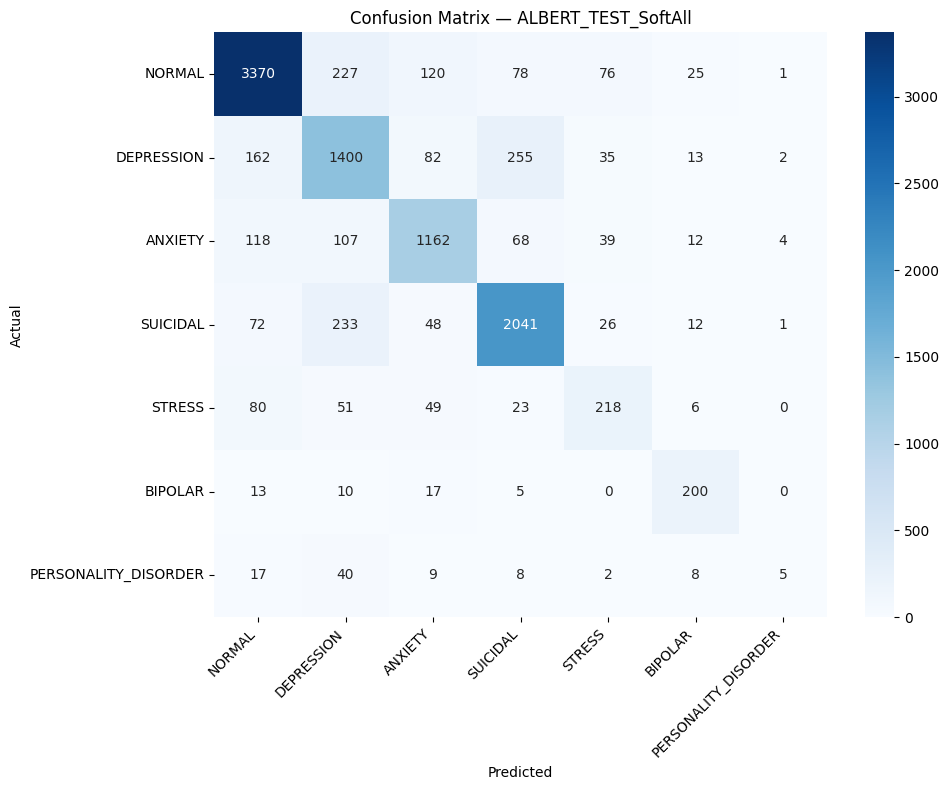

Saved → ./05_SoftLabel_TrainAll/outputs/ALBERT_TEST_SoftAll_roc_curve.png


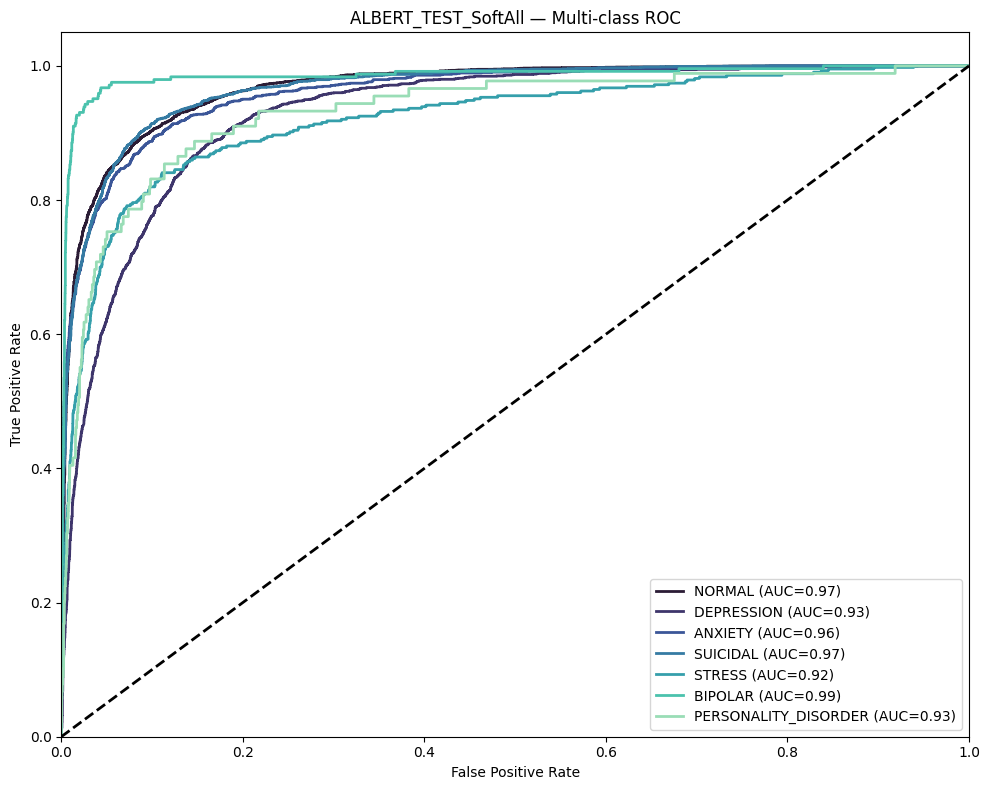


--- Evaluation (SOFT): ALBERT_TEST ---
Soft CE: 0.816126  95% CI [0.796633, 0.834200]
Brier:   0.240808  95% CI [0.232464, 0.248744]

Evaluation (HARD): ALBERT_VAL
                      precision    recall  f1-score   support

              NORMAL     0.8768    0.8690    0.8729      3824
          DEPRESSION     0.7095    0.7164    0.7129      1936
             ANXIETY     0.7974    0.8068    0.8021      1532
            SUICIDAL     0.8345    0.8497    0.8420      2468
              STRESS     0.5363    0.4842    0.5089       442
             BIPOLAR     0.6846    0.8608    0.7626       237
PERSONALITY_DISORDER     0.7500    0.1154    0.2000        78

            accuracy                         0.8054     10517
           macro avg     0.7413    0.6717    0.6716     10517
        weighted avg     0.8049    0.8054    0.8031     10517

Weighted F1: 0.8030  95% CI [0.7951, 0.8111]
Macro AUC:   0.9524  95% CI [0.9481, 0.9566]
Saved → ./05_SoftLabel_TrainAll/outputs/ALBERT_VAL_SoftAll_c

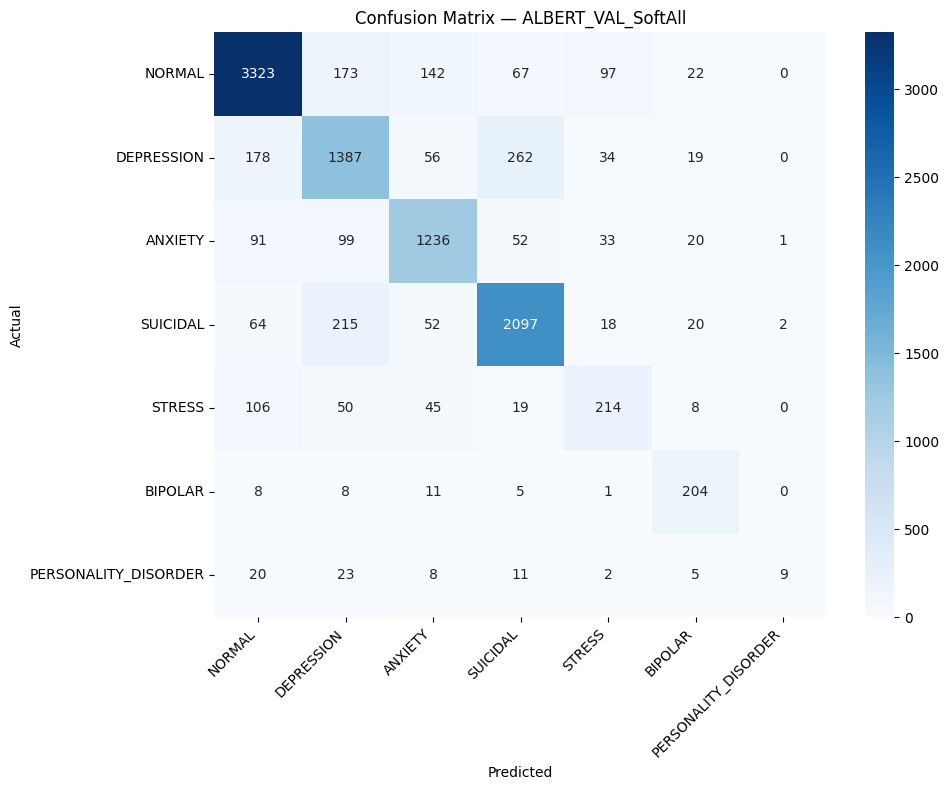

Saved → ./05_SoftLabel_TrainAll/outputs/ALBERT_VAL_SoftAll_roc_curve.png


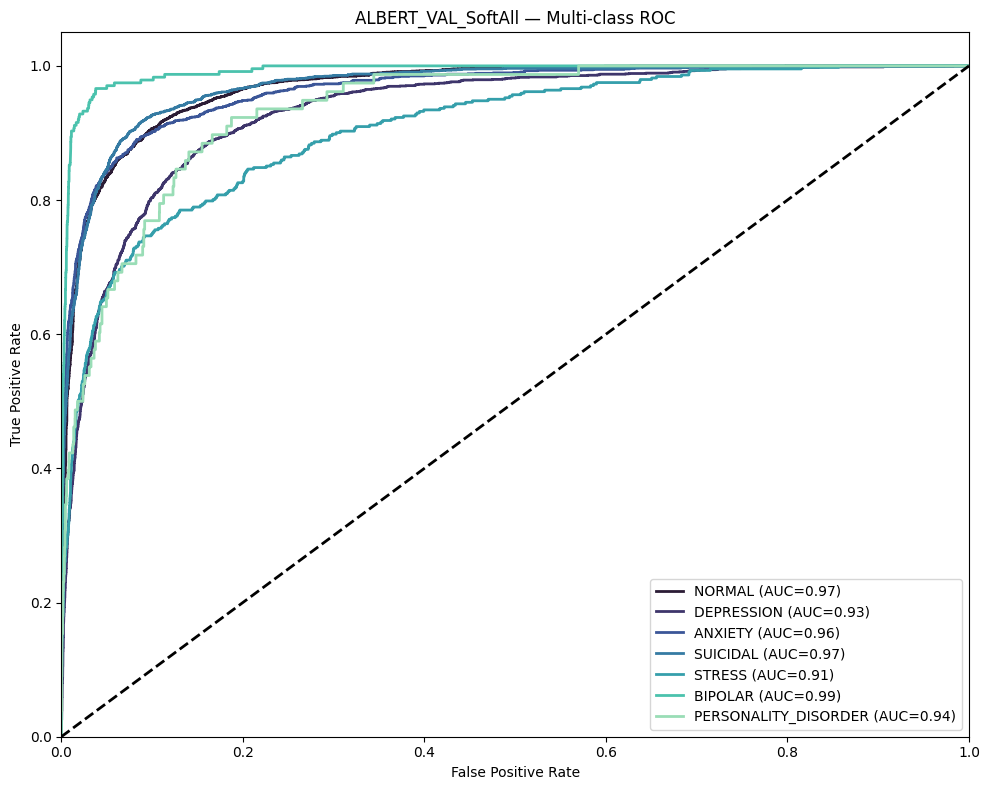


--- Evaluation (SOFT): ALBERT_VAL ---
Soft CE: 0.808037  95% CI [0.789947, 0.826105]
Brier:   0.237820  95% CI [0.230337, 0.245396]


In [20]:
# Hard evaluation
test_logits_a, test_y_hard_a, test_y_soft_a = predict_logits(
    best_albert, test_loader_albert, DEVICE)
test_probs_a = torch.softmax(torch.tensor(test_logits_a), dim=1).numpy()

albert_hard_results = evaluate_hard(
    test_y_hard_a, test_logits_a, CLASS_NAMES,
    model_tag="ALBERT_TEST", save_dir=str(OUTPUT_PATH))

# Soft evaluation
albert_soft_results = evaluate_soft(
    test_probs_a, test_y_soft_a, model_tag="ALBERT_TEST")

# Val evaluation (for comparison)
val_logits_a, val_y_hard_a, val_y_soft_a = predict_logits(
    best_albert, val_loader_albert, DEVICE)
val_probs_a = torch.softmax(torch.tensor(val_logits_a), dim=1).numpy()

albert_val_hard = evaluate_hard(
    val_y_hard_a, val_logits_a, CLASS_NAMES,
    model_tag="ALBERT_VAL", save_dir=str(OUTPUT_PATH))
albert_val_soft = evaluate_soft(
    val_probs_a, val_y_soft_a, model_tag="ALBERT_VAL")

## 3.5 BioBERT

In [21]:
print("\n" + "=" * 60)
print("BioBERT — 7-Class Soft-Label Training (Mental Health)")
print("=" * 60)


BioBERT — 7-Class Soft-Label Training (Mental Health)


### 3.5.1 Pre-tokenize

In [22]:
biobert_tokenizer = BertTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [23]:
if RETRAIN:
    set_seed()
    start = time.time()

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Soft 7-Class"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
        model = TransformerClassifier(
            base, base.config.hidden_size,
            num_classes=NUM_CLASSES, dropout=hp["dropout"],
        )

        f1_val, model, best_ep, history = train_soft_model(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
    best_biobert = TransformerClassifier(
        base, base.config.hidden_size,
        num_classes=NUM_CLASSES,
        dropout=best_params_biobert.get("dropout", 0.1),
    )
    best_biobert.load_state_dict(
        torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE)
    )

best_biobert.to(DEVICE)
best_biobert.eval()

BioBERT Soft 7-Class:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Epoch 1/9 | TrainLoss=1.0034 | ValSoftLoss=0.8452 | ValF1=0.7722
  Epoch 2/9 | TrainLoss=0.7854 | ValSoftLoss=0.8237 | ValF1=0.7776
  Epoch 3/9 | TrainLoss=0.6889 | ValSoftLoss=0.8286 | ValF1=0.7855
  Epoch 4/9 | TrainLoss=0.6047 | ValSoftLoss=0.8537 | ValF1=0.7898
  Epoch 5/9 | TrainLoss=0.5359 | ValSoftLoss=0.9153 | ValF1=0.7781
  Epoch 6/9 | TrainLoss=0.4838 | ValSoftLoss=0.9344 | ValF1=0.7760
  Epoch 7/9 | TrainLoss=0.4550 | ValSoftLoss=0.9604 | ValF1=0.7758
  Early stopping at epoch 7.


BioBERT Soft 7-Class: 100%|██████████| 10/10 [33:27<00:00, 200.79s/it]


BioBERT tuning: 2007.9s | Best F1=0.7898
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.22900784668310975}


TransformerClassifier(
  (base): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

### 3.4.3 Model evaluation


Evaluation (HARD): BioBERT_TEST
                      precision    recall  f1-score   support

              NORMAL     0.8698    0.8709    0.8704      3897
          DEPRESSION     0.6675    0.6983    0.6825      1949
             ANXIETY     0.7554    0.7609    0.7582      1510
            SUICIDAL     0.8149    0.8360    0.8253      2433
              STRESS     0.5862    0.3981    0.4742       427
             BIPOLAR     0.7222    0.7429    0.7324       245
PERSONALITY_DISORDER     0.3400    0.1910    0.2446        89

            accuracy                         0.7874     10550
           macro avg     0.6794    0.6426    0.6554     10550
        weighted avg     0.7840    0.7874    0.7847     10550

Weighted F1: 0.7847  95% CI [0.7764, 0.7927]
Macro AUC:   0.9502  95% CI [0.9467, 0.9537]
Saved → ./05_SoftLabel_TrainAll/outputs/BioBERT_TEST_SoftAll_confusion_matrix.png


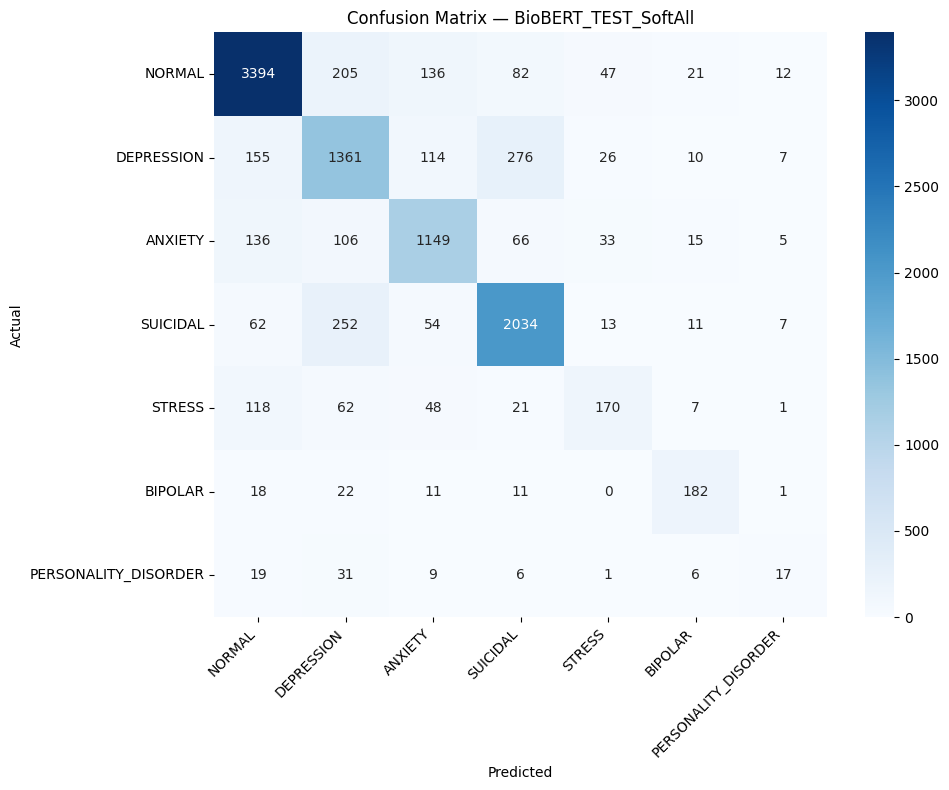

Saved → ./05_SoftLabel_TrainAll/outputs/BioBERT_TEST_SoftAll_roc_curve.png


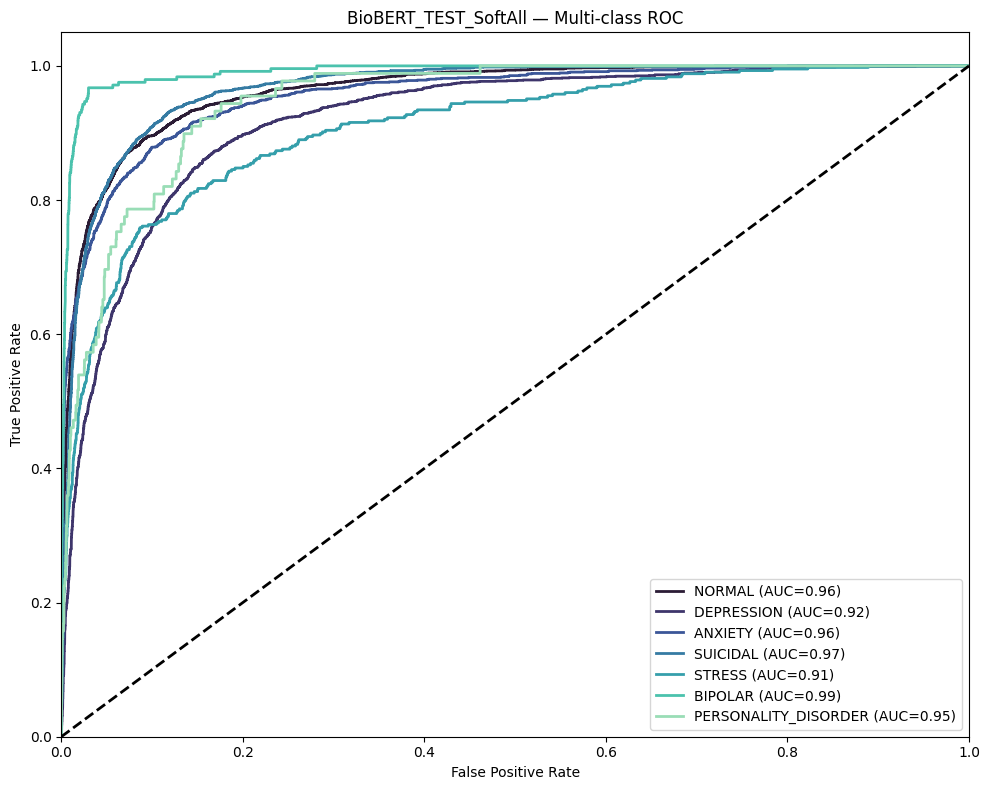


--- Evaluation (SOFT): BioBERT_TEST ---
Soft CE: 0.855809  95% CI [0.835569, 0.875736]
Brier:   0.255573  95% CI [0.246829, 0.263706]

Evaluation (HARD): BioBERT_VAL
                      precision    recall  f1-score   support

              NORMAL     0.8570    0.8729    0.8649      3824
          DEPRESSION     0.6845    0.7061    0.6951      1936
             ANXIETY     0.7697    0.7702    0.7700      1532
            SUICIDAL     0.8329    0.8485    0.8406      2468
              STRESS     0.5884    0.3688    0.4534       442
             BIPOLAR     0.7121    0.7722    0.7409       237
PERSONALITY_DISORDER     0.4091    0.2308    0.2951        78

            accuracy                         0.7933     10517
           macro avg     0.6934    0.6528    0.6657     10517
        weighted avg     0.7890    0.7933    0.7898     10517

Weighted F1: 0.7897  95% CI [0.7820, 0.7976]
Macro AUC:   0.9458  95% CI [0.9405, 0.9509]
Saved → ./05_SoftLabel_TrainAll/outputs/BioBERT_VAL_SoftAl

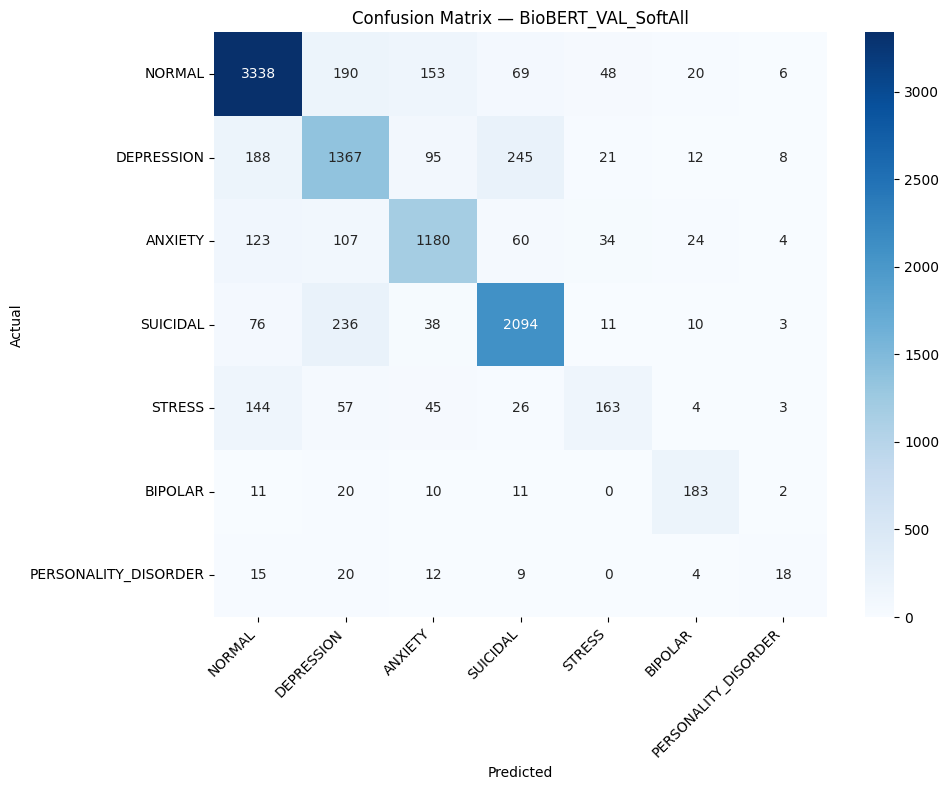

Saved → ./05_SoftLabel_TrainAll/outputs/BioBERT_VAL_SoftAll_roc_curve.png


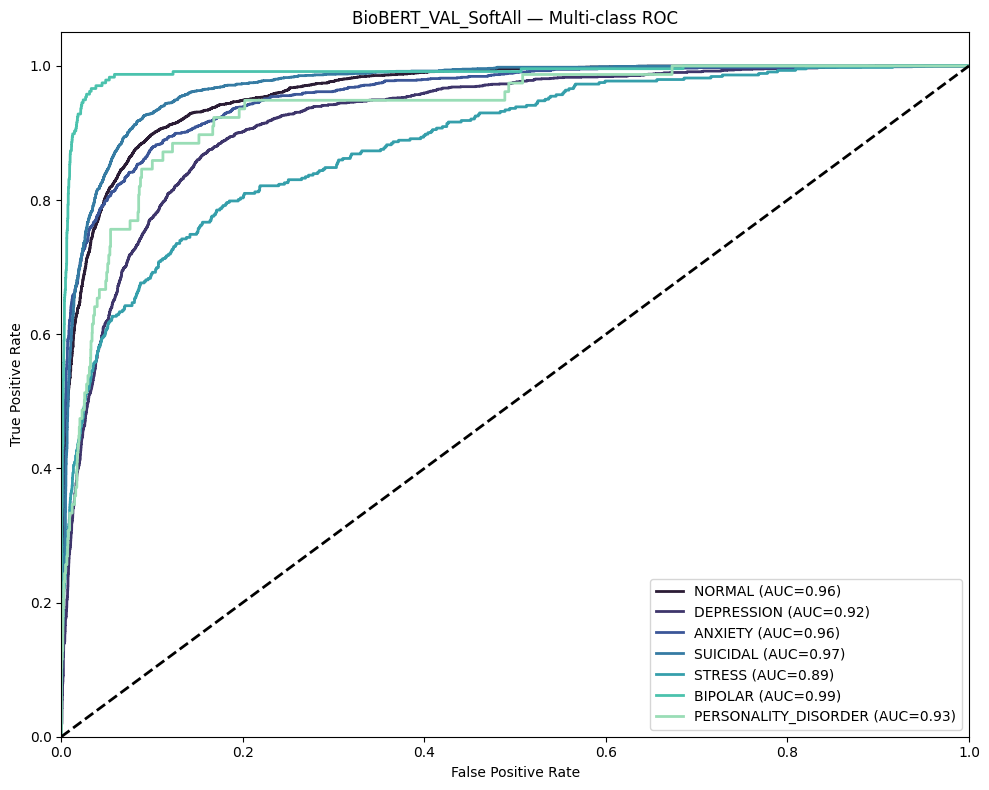


--- Evaluation (SOFT): BioBERT_VAL ---
Soft CE: 0.849519  95% CI [0.829486, 0.871353]
Brier:   0.254315  95% CI [0.246182, 0.262862]


In [24]:
# Hard evaluation
test_logits_b, test_y_hard_b, test_y_soft_b = predict_logits(
    best_biobert, test_loader_biobert, DEVICE)
test_probs_b = torch.softmax(torch.tensor(test_logits_b), dim=1).numpy()

biobert_hard_results = evaluate_hard(
    test_y_hard_b, test_logits_b, CLASS_NAMES,
    model_tag="BioBERT_TEST", save_dir=str(OUTPUT_PATH))

# Soft evaluation
biobert_soft_results = evaluate_soft(
    test_probs_b, test_y_soft_b, model_tag="BioBERT_TEST")

# Val evaluation
val_logits_b, val_y_hard_b, val_y_soft_b = predict_logits(
    best_biobert, val_loader_biobert, DEVICE)
val_probs_b = torch.softmax(torch.tensor(val_logits_b), dim=1).numpy()

biobert_val_hard = evaluate_hard(
    val_y_hard_b, val_logits_b, CLASS_NAMES,
    model_tag="BioBERT_VAL", save_dir=str(OUTPUT_PATH))
biobert_val_soft = evaluate_soft(
    val_probs_b, val_y_soft_b, model_tag="BioBERT_VAL")

## 3.6 Save prediction

In [25]:
df_test_out = df_test[[TEXT_COLUMN, "y_hard"]].copy()
df_test_out["albert_pred"] = albert_hard_results["y_pred"]
df_test_out["biobert_pred"] = biobert_hard_results["y_pred"]

for i, name in enumerate(CLASS_NAMES):
    df_test_out[f"albert_p_{name}"] = albert_hard_results["y_prob"][:, i]
    df_test_out[f"biobert_p_{name}"] = biobert_hard_results["y_prob"][:, i]

pred_path = OUTPUT_PATH / "test_predictions_soft_all.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

print("\n" + "=" * 60)
print("SUMMARY — 7-Class Soft-Label All (Mental Health)")
print("=" * 60)

for model_name, hard_r, soft_r in [
    ("ALBERT", albert_hard_results, albert_soft_results),
    ("BioBERT", biobert_hard_results, biobert_soft_results),
]:
    print(f"\n{model_name}:")
    print(f"  Weighted F1: {hard_r['f1_weighted']:.4f} "
          f"[{hard_r['f1_ci'][0]:.4f}, {hard_r['f1_ci'][1]:.4f}]")
    print(f"  Macro AUC:   {hard_r['auc_macro']:.4f} "
          f"[{hard_r['auc_ci'][0]:.4f}, {hard_r['auc_ci'][1]:.4f}]")
    print(f"  Soft CE:     {soft_r['soft_ce']:.6f} "
          f"[{soft_r['soft_ce_ci'][0]:.6f}, {soft_r['soft_ce_ci'][1]:.6f}]")
    print(f"  Brier:       {soft_r['brier']:.6f} "
          f"[{soft_r['brier_ci'][0]:.6f}, {soft_r['brier_ci'][1]:.6f}]")


Saved predictions → ./05_SoftLabel_TrainAll/outputs/test_predictions_soft_all.csv

SUMMARY — 7-Class Soft-Label All (Mental Health)

ALBERT:
  Weighted F1: 0.7937 [0.7862, 0.8015]
  Macro AUC:   0.9518 [0.9463, 0.9568]
  Soft CE:     0.816126 [0.796633, 0.834200]
  Brier:       0.240808 [0.232464, 0.248744]

BioBERT:
  Weighted F1: 0.7847 [0.7764, 0.7927]
  Macro AUC:   0.9502 [0.9467, 0.9537]
  Soft CE:     0.855809 [0.835569, 0.875736]
  Brier:       0.255573 [0.246829, 0.263706]
